# Regressão Linear Múltipla

O [Módulo 05](../05_Correlação_e_Regressão_Linear) modelou a relação entre duas
variáveis. Este módulo generaliza para **múltiplas variáveis explicativas** — o modelo de
trabalho padrão em Econometria — e ensina a **validar** se o modelo é confiável:
pressupostos, testes de hipótese sobre os coeficientes, e diagnósticos de problemas
comuns.

Pré-requisitos: [Módulo 05](../05_Correlação_e_Regressão_Linear),
[Módulo 06](../06_Estatística_Econômica_e_Números_Índices)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update({'font.size': 12})
rng = np.random.default_rng(7)

## 1. O modelo de regressão múltipla

$$Y_i = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \dots + \beta_k X_{ki} + u_i$$

Ainda estimado por Mínimos Quadrados Ordinários (MQO/OLS) — minimizando a soma dos
quadrados dos resíduos — só que agora cada $\beta_j$ mede o efeito de $X_j$ **mantendo
as demais variáveis explicativas constantes** (efeito parcial/ceteris paribus).

### O dado: custos de companhias aéreas

Usamos um conjunto de dados clássico da literatura de econometria (Christensen & Greene) —
6 companhias aéreas americanas observadas ao longo de 15 anos (1970–1984): custo total
(C), produção/output (Q), preço do combustível (PF) e índice de utilização da frota
(*load factor*, LF). Todas as variáveis já vêm em log, o que torna os coeficientes
diretamente interpretáveis como **elasticidades**.

In [2]:
df = pd.read_csv('airline_costs.csv')
print(f"{df.shape[0]} observações — {df['I'].nunique()} companhias × {df['T'].nunique()} anos ({df['T'].min()}-{df['T'].max()})")
df[['I', 'T', 'C', 'Q', 'PF', 'LF', 'ln_C', 'ln_Q', 'ln_PF', 'ln_LF']].head()

90 observações — 6 companhias × 15 anos (1970-1984)


,I,T,C,Q,PF,LF,ln_C,ln_Q,ln_PF,ln_LF
0,1,1970,1140640,0.952757,106650,0.534487,13.947100,-0.048395,11.577308,-0.626448
1,1,1971,1215690,0.986757,110307,0.532328,14.010822,-0.013331,11.611023,-0.630495
2,1,1972,1309570,1.091980,110574,0.547736,14.085209,0.087993,11.613440,-0.601962
3,1,1973,1511530,1.175780,121974,0.540846,14.228633,0.161932,11.711563,-0.614621
4,1,1974,1676730,1.160170,196606,0.591167,14.332356,0.148567,12.188957,-0.525657


### Função de custo Cobb-Douglas (regressão múltipla)

$$\ln(C) = \beta_0 + \beta_1 \ln(Q) + \beta_2 \ln(PF) + \beta_3 \ln(LF) + u$$

Por enquanto tratamos os dados como um único conjunto (*pooled*), ignorando que vêm de
apenas 6 empresas repetidas — essa estrutura de painel é o assunto do
[Módulo 08](../08_Econometria_II).

In [3]:
X = sm.add_constant(df[['ln_Q', 'ln_PF', 'ln_LF']])
y = df['ln_C']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   ln_C   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     2411.
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           7.58e-83
Time:                        02:25:41   Log-Likelihood:                 61.624
No. Observations:                  90   AIC:                            -115.2
Df Residuals:                      86   BIC:                            -105.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0756      0.334     24.164      0.0

## 2. Pressupostos de Gauss-Markov

Sob estes pressupostos, o estimador de MQO é o **BLUE** (*Best Linear Unbiased
Estimator* — o estimador linear não-viesado de menor variância possível):

1. **Linearidade nos parâmetros** — o modelo é linear em $\beta$ (as próprias
   variáveis podem ser não-lineares, como aqui com os logs).
2. **Amostragem aleatória** — as observações são extraídas aleatoriamente da população.
3. **Não-colinearidade perfeita** — nenhuma variável explicativa é combinação linear
   exata das outras (sem isso, o MQO nem consegue ser calculado).
4. **Exogeneidade** — $E(u \mid X) = 0$: o erro não é correlacionado com nenhuma
   variável explicativa (viés de variável omitida quebra este pressuposto).
5. **Homocedasticidade** — $Var(u \mid X) = \sigma^2$ constante (seção 6 testa isso).

Um sexto pressuposto (normalidade dos erros) não é necessário para o MQO ser BLUE, mas é
necessário para os testes t e F terem validade exata em amostras pequenas.

## 3. Teste de significância individual (teste t)

Testa, para cada coeficiente: $H_0: \beta_j = 0$ (a variável não tem efeito parcial
sobre $Y$) contra $H_1: \beta_j \neq 0$. A tabela do `summary()` acima já traz a
estatística t e o p-valor de cada coeficiente — todos os três, aqui, são significativos a
1% (p-valor < 0,001).

Como o modelo está em log-log, cada coeficiente é lido diretamente como elasticidade:

In [4]:
for var in ['ln_Q', 'ln_PF', 'ln_LF']:
    coef = modelo.params[var]
    print(f"1% de aumento em {var[3:]} está associado a {coef:.2f}% de variação no custo, tudo o mais constante.")

1% de aumento em Q está associado a 0.88% de variação no custo, tudo o mais constante.
1% de aumento em PF está associado a 0.45% de variação no custo, tudo o mais constante.
1% de aumento em LF está associado a -0.89% de variação no custo, tudo o mais constante.


### Exercício de interpretação — significância a diferentes níveis

Um modelo estimado $\ln(Y) = \beta_0 + \beta_1\ln(X_1) + \beta_2\ln(X_2) + \beta_3\ln(X_3)$
trouxe os seguintes p-valores: $\beta_1$: 0,9477 · $\beta_2$: 0,0523 · $\beta_3$: 0,0012.
A 5% de significância, quantos coeficientes (excluindo a constante) são
estatisticamente diferentes de zero?

In [5]:
p_valores = {'b1': 0.9477, 'b2': 0.0523, 'b3': 0.0012}
alpha = 0.05
significativos = [k for k, p in p_valores.items() if p < alpha]
print(f"Significativos a {alpha:.0%}: {significativos}")
print("(b2 fica de fora por pouco — seria significativo a 10%, mas não a 5%.)")

Significativos a 5%: ['b3']
(b2 fica de fora por pouco — seria significativo a 10%, mas não a 5%.)


## 4. Teste de significância conjunta (teste F)

Enquanto o teste t avalia cada coeficiente isoladamente, o teste F avalia **todos ao
mesmo tempo**: $H_0: \beta_1=\beta_2=\dots=\beta_k=0$ (nenhuma das variáveis explica
$Y$) contra $H_1$: pelo menos uma é diferente de zero.

In [6]:
print(f"Estatística F = {modelo.fvalue:.1f}")
print(f"p-valor do teste F = {modelo.f_pvalue:.2e}")
print("\np-valor essencialmente zero: rejeitamos H0 com folga — o modelo, em conjunto,")
print("explica significativamente a variação do custo (o que já era esperado com R² tão alto).")

Estatística F = 2411.4
p-valor do teste F = 7.58e-83

p-valor essencialmente zero: rejeitamos H0 com folga — o modelo, em conjunto,
explica significativamente a variação do custo (o que já era esperado com R² tão alto).


## 5. R² e R² ajustado

$R^2$ sempre **aumenta** (ou fica igual) quando se adiciona qualquer variável ao modelo —
mesmo uma sem relação real com $Y$. O $R^2$ ajustado penaliza a inclusão de variáveis
irrelevantes:

$$\bar{R}^2 = 1 - (1-R^2)\frac{n-1}{n-k-1}$$

### Demonstração — adicionando uma variável aleatória (sem relação com o custo)

In [7]:
df_teste = df.copy()
df_teste['ruido'] = rng.normal(size=len(df_teste))  # variável sem nenhuma relação real com o custo

X_com_ruido = sm.add_constant(df_teste[['ln_Q', 'ln_PF', 'ln_LF', 'ruido']])
modelo_com_ruido = sm.OLS(y, X_com_ruido).fit()

print(f"{'Modelo':<20}{'R²':>10}{'R² ajustado':>15}")
print(f"{'original (3 vars)':<20}{modelo.rsquared:>10.5f}{modelo.rsquared_adj:>15.5f}")
print(f"{'com ruído (4 vars)':<20}{modelo_com_ruido.rsquared:>10.5f}{modelo_com_ruido.rsquared_adj:>15.5f}")
print(f"\np-valor da variável 'ruido': {modelo_com_ruido.pvalues['ruido']:.3f} (não significativa, como esperado)")

Modelo                      R²    R² ajustado
original (3 vars)      0.98825        0.98784
com ruído (4 vars)     0.98850        0.98796

p-valor da variável 'ruido': 0.176 (não significativa, como esperado)


$R^2$ subiu (nem que seja no quinto dígito) mesmo a variável sendo pura aleatoriedade
— $R^2$ ajustado, por outro lado, caiu, corretamente sinalizando que a variável não ajuda o
modelo. É por isso que $R^2$ ajustado é o critério certo para **comparar** modelos com
número diferente de variáveis.

## 6. Variáveis dummy

Uma variável dummy (0/1) permite que categorias tenham **interceptos diferentes** no
mesmo modelo. Cada companhia aérea provavelmente tem uma estrutura de custo fixa
diferente — vamos capturar isso com dummies por empresa (deixando a primeira como
categoria de referência, para evitar a "armadilha da dummy": colinearidade perfeita se
incluíssemos uma dummy para cada categoria mais o intercepto).

In [8]:
dummies_empresa = pd.get_dummies(df['I'], prefix='empresa', drop_first=True, dtype=int)
X_dummies = sm.add_constant(pd.concat([df[['ln_Q', 'ln_PF', 'ln_LF']], dummies_empresa], axis=1))

modelo_dummies = sm.OLS(y, X_dummies).fit()
print(modelo_dummies.summary().tables[1])
print(f"\nR² subiu de {modelo.rsquared:.4f} para {modelo_dummies.rsquared:.4f} ao permitir")
print("um intercepto próprio por empresa — indício de que há heterogeneidade entre")
print("empresas que o modelo pooled original ignorava. Isso é exatamente o que o")
print("Módulo 08 formaliza como modelo de Efeitos Fixos.")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.8020      0.215     41.016      0.000       8.375       9.229
ln_Q           0.9187      0.031     29.958      0.000       0.858       0.980
ln_PF          0.4158      0.015     26.845      0.000       0.385       0.447
ln_LF         -0.5527      0.113     -4.880      0.000      -0.778      -0.327
empresa_2     -0.0365      0.026     -1.428      0.157      -0.087       0.014
empresa_3     -0.2072      0.044     -4.722      0.000      -0.294      -0.120
empresa_4      0.1865      0.062      3.001      0.004       0.063       0.310
empresa_5      0.0249      0.082      0.305      0.762      -0.138       0.188
empresa_6      0.0920      0.086      1.067      0.289      -0.079       0.263

R² subiu de 0.9883 para 0.9973 ao permitir
um intercepto próprio por empresa — indício de que há heterogeneidade entre
empresas qu

## 7. Diagnóstico: multicolinearidade (VIF)

O *Variance Inflation Factor* mede o quanto a variância de um coeficiente é "inflada" por
colinearidade com as outras variáveis explicativas. Regra prática: VIF > 10 (alguns usam
> 5) é sinal de alerta.

In [9]:
vif_dados = pd.DataFrame({
    'variável': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_dados)
print("\nTodas as variáveis explicativas têm VIF bem abaixo de 5 — sem evidência de")
print("multicolinearidade problemática neste modelo (o VIF alto da constante não conta:")
print("é esperado e não indica problema).")

  variável         VIF
0    const  645.239218
1     ln_Q    1.338271
2    ln_PF    1.578278
3    ln_LF    1.934840

Todas as variáveis explicativas têm VIF bem abaixo de 5 — sem evidência de
multicolinearidade problemática neste modelo (o VIF alto da constante não conta:
é esperado e não indica problema).


## 8. Diagnóstico: heterocedasticidade

Homocedasticidade (pressuposto de Gauss-Markov #5) significa que a variância do erro é
constante — não aumenta nem diminui sistematicamente com o nível das variáveis
explicativas. O teste de **Breusch-Pagan** formaliza essa checagem:
$H_0$: homocedasticidade.

In [10]:
bp_stat, bp_pvalue, _, _ = het_breuschpagan(modelo.resid, X)
print(f"Estatística LM de Breusch-Pagan = {bp_stat:.4f}")
print(f"p-valor = {bp_pvalue:.4f}")

if bp_pvalue < 0.05:
    print("\np-valor < 5%: rejeitamos H0 — há evidência de heterocedasticidade.")
else:
    print("\np-valor > 5%: não rejeitamos H0 — sem evidência forte de heterocedasticidade")
    print("(a transformação em log já costuma suavizar boa parte desse problema).")

Estatística LM de Breusch-Pagan = 4.2732
p-valor = 0.2334

p-valor > 5%: não rejeitamos H0 — sem evidência forte de heterocedasticidade
(a transformação em log já costuma suavizar boa parte desse problema).


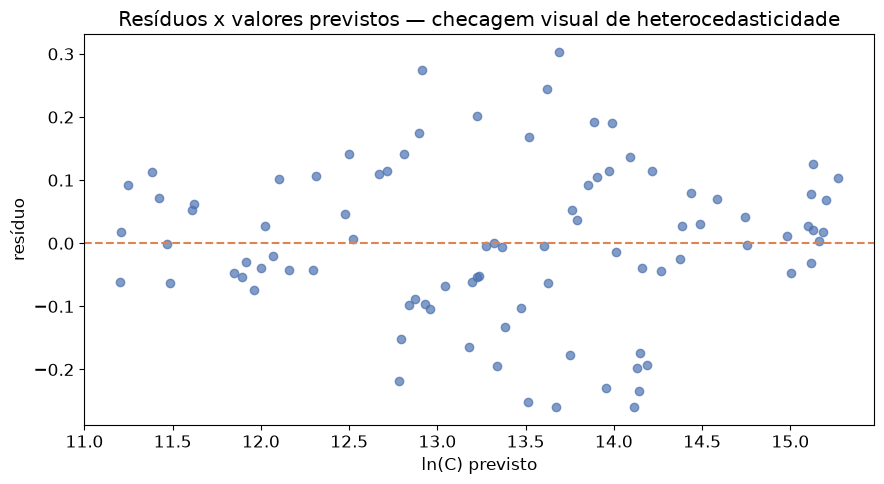

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(modelo.fittedvalues, modelo.resid, color='#4C72B0', alpha=0.7)
ax.axhline(0, color='#DD8452', linestyle='--')
ax.set_title('Resíduos x valores previstos — checagem visual de heterocedasticidade')
ax.set_xlabel('ln(C) previsto')
ax.set_ylabel('resíduo')
plt.tight_layout()
plt.savefig('img_residuos_heterocedasticidade.png', dpi=110)
plt.show()

### Um alerta que o modelo pooled esconde

Vale reparar em uma estatística que apareceu no `summary()` da seção 1 e que este módulo
não formaliza: o **Durbin-Watson** do modelo original ficou bem abaixo de 2 — sinal de
autocorrelação nos resíduos. Isso não é surpresa: como o mesmo grupo de 6 empresas é
observado repetidamente ao longo de 15 anos, tratar tudo como uma amostra
independente "pooled" ignora a estrutura de painel dos dados. É exatamente esse problema
que o [Módulo 08](../08_Econometria_II) resolve com Efeitos Fixos e Efeitos Aleatórios —
usando este mesmo dataset.

## 9. Exercícios de fixação

Um analista estimou o modelo $\ln(C_t) = \beta_0 + \beta_1\ln(E_t) + \beta_2\ln(EE_t) + u_t$
para o custo unitário de um produto industrial, onde $E$ é a taxa de câmbio e $EE$ é o
preço da energia elétrica (ambos coeficientes significativos a 10%): $\beta_1 = 0{,}50$
e $\beta_2 = 1{,}10$. Um cenário prevê depreciação cambial de 15% e queda de 10% no preço
da energia.

1. Qual o impacto, tudo o mais constante, da depreciação cambial sobre o custo unitário?
2. Qual o impacto **conjunto** dos dois efeitos sobre o custo unitário?

In [12]:
beta1, beta2 = 0.50, 1.10
var_cambio, var_energia = 0.15, -0.10   # variações percentuais previstas

impacto_cambio = beta1 * var_cambio
impacto_conjunto = beta1 * var_cambio + beta2 * var_energia

print(f"1) impacto isolado da depreciação cambial: {impacto_cambio:+.1%}")
print(f"2) impacto conjunto (câmbio + energia):     {impacto_conjunto:+.1%}")

1) impacto isolado da depreciação cambial: +7.5%
2) impacto conjunto (câmbio + energia):     -3.5%


## Encerramento do módulo

Com regressão múltipla, Gauss-Markov, testes t/F, R² ajustado, dummies e diagnósticos de
multicolinearidade/heterocedasticidade, o Módulo 07 está completo. O
[Módulo 08 — Econometria II](../08_Econometria_II) retoma este mesmo dataset de
companhias aéreas para tratá-lo corretamente como **dados em painel**.

## Bibliografia
- WOOLDRIDGE, Jeffrey M. *Introdução à Econometria: uma abordagem moderna*. São Paulo: Cengage Learning, 2016.
- GUJARATI, Damodar N.; PORTER, Dawn C. *Econometria Básica*. 5. ed. Porto Alegre: AMGH, 2011.
- GREENE, William H. *Econometric Analysis*. 8. ed. Pearson, 2018. (fonte do dataset de custos de companhias aéreas, originalmente de Christensen & Greene, 1976)
- STOCK, James H.; WATSON, Mark W. *Introduction to Econometrics*. 4. ed. Pearson, 2019.